<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/An_EfficientNetV2B0%E2%80%93Transformer_Hybrid_Framework_for_Binary_Arsenic_Skin_Disease_Classification_on_the_ArsenicSkinImagesBD_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight

import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize

In [36]:
train_path = "/content/drive/MyDrive/ArsenicSkinImagesBD/Train"
test_path = "/content/drive/MyDrive/ArsenicSkinImagesBD/Test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [37]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [38]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print("Number of classes:", NUM_CLASSES)
print(train_generator.class_indices)

Found 6659 images belonging to 2 classes.
Found 2233 images belonging to 2 classes.
Number of classes: 2
{'infected': 0, 'not_infected': 1}


In [39]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9977524722804915), 1: np.float64(1.0022576760987356)}


Transformer Block

In [40]:
def transformer_block(x):

    attn = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=x.shape[-1]//4
    )(x, x)

    x1 = layers.Add()([x, attn])
    x1 = layers.LayerNormalization()(x1)

    ffn = layers.Dense(
        x.shape[-1]*2,
        activation='gelu'
    )(x1)

    ffn = layers.Dense(
        x.shape[-1]
    )(ffn)

    x2 = layers.Add()([x1, ffn])
    x2 = layers.LayerNormalization()(x2)

    return x2

In [41]:
def build_model(num_classes):

    inputs = layers.Input(shape=(224,224,3))

    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    # Fine-tune last 20 layers
    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    h, w, c = x.shape[1], x.shape[2], x.shape[3]

    patches = h * w

    x = layers.Reshape((patches, c))(x)

    pos = tf.range(start=0, limit=patches, delta=1)

    pos_emb = layers.Embedding(
        input_dim=patches,
        output_dim=c
    )(pos)

    x = x + pos_emb

    # Transformer Block 1
    x = transformer_block(x)

    # Transformer Block 2
    x = transformer_block(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        512,
        activation='relu'
    )(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        256,
        activation='relu'
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = models.Model(inputs, outputs)

    return model

In [42]:
model = build_model(NUM_CLASSES)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,949,586 (125.69 MB)

 Trainable params: 27,848,114 (106.23 MB)

 Non-trainable params: 5,101,472 (19.46 MB)

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
callbacks_list = [

    callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [12]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8377 - loss: 0.4401
Epoch 1: val_accuracy improved from None to 0.90013, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 2477s 12s/step - accuracy: 0.8970 - loss: 0.2986 - val_accuracy: 0.9001 - val_loss: 0.2408 - learning_rate: 3.0000e-04
Epoch 2/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9582 - loss: 0.1212
Epoch 2: val_accuracy improved from 0.90013 to 0.90282, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 2152s 10s/step - accuracy: 0.9555 - loss: 0.1315 - val_accuracy: 0.9028 - val_loss: 0.5348 - learning_rate: 3.0000e-04
Epoch 3/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9626 - loss: 0.1261
Epoch 3: val_accuracy improved from 0.90282 to 0.93820, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 

In [13]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

70/70 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.9619 - loss: 0.1138
Test Loss : 0.1138
Test Accuracy : 96.19 %


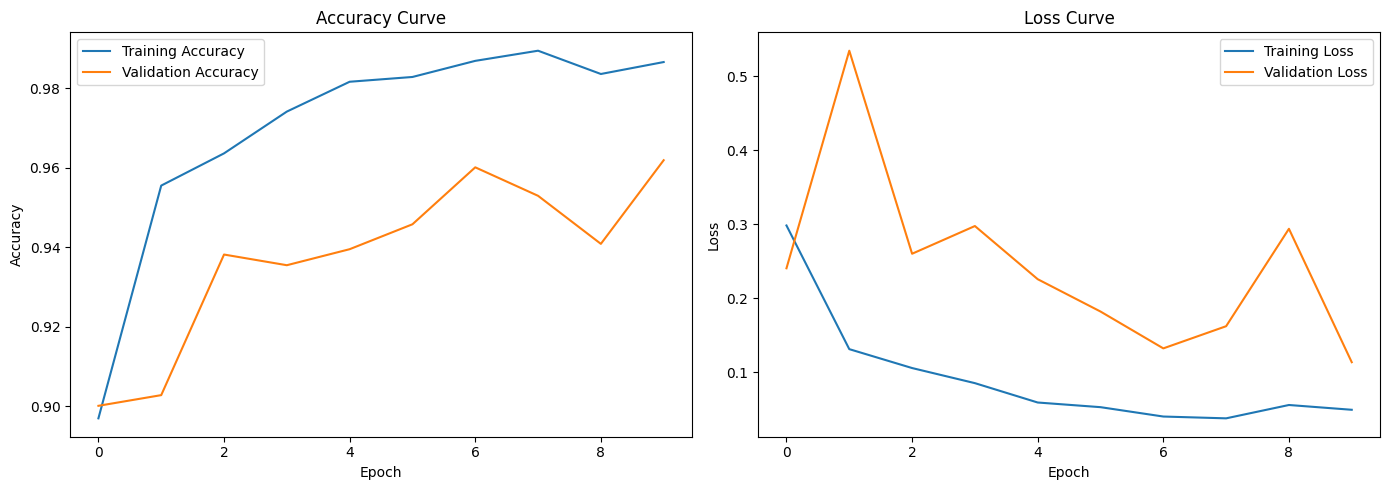

In [22]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

num_classes = len(class_names)

70/70 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step


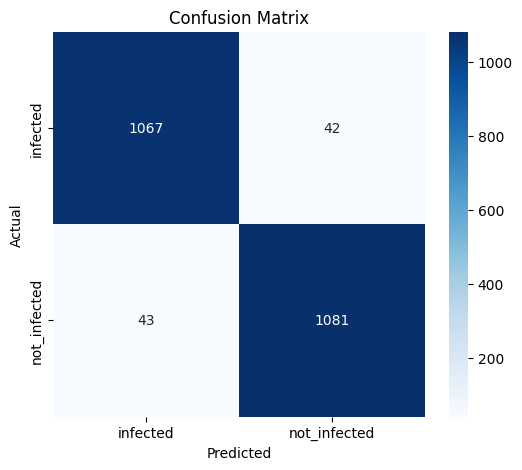

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [25]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    infected       0.96      0.96      0.96      1109
not_infected       0.96      0.96      0.96      1124

    accuracy                           0.96      2233
   macro avg       0.96      0.96      0.96      2233
weighted avg       0.96      0.96      0.96      2233



In [26]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision : {:.2f}%".format(precision*100))
print("Recall    : {:.2f}%".format(recall*100))
print("F1 Score  : {:.2f}%".format(f1*100))

Precision : 96.19%
Recall    : 96.19%
F1 Score  : 96.19%


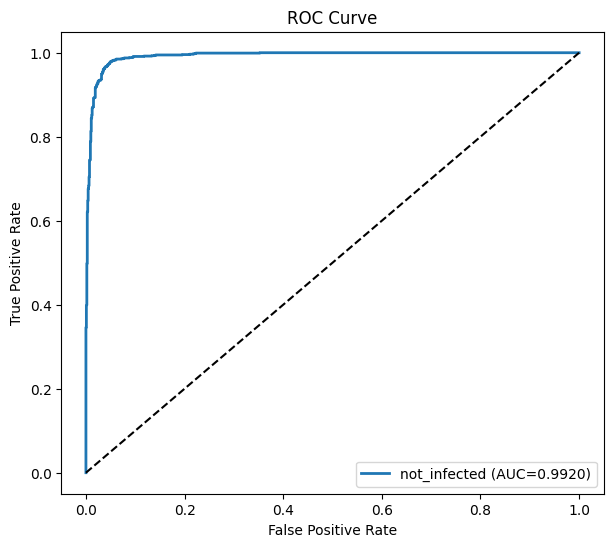

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Number of classes
num_classes = len(class_names)

plt.figure(figsize=(7,6))

if num_classes == 2:
    # Binary classification
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{class_names[1]} (AUC={roc_auc:.4f})'
    )

else:
    # Multiclass classification
    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(num_classes)
    )

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            y_pred_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f'{class_names[i]} (AUC={roc_auc:.4f})'
        )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
plt.show()

In [31]:
print("AUC Values")

if num_classes == 2:
    print(f"{class_names[1]} : {roc_auc:.4f}")
else:
    for i in range(num_classes):
        print(f"{class_names[i]} : {roc_auc[i]:.4f}")

AUC Values
not_infected : 0.9920


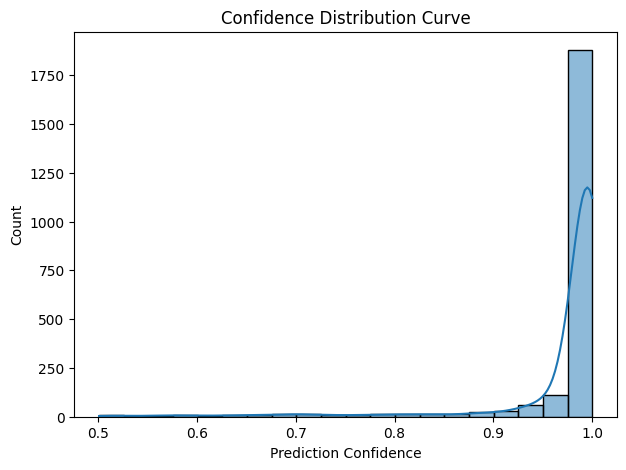

In [32]:
confidence = np.max(y_pred_prob, axis=1)

plt.figure(figsize=(7,5))

sns.histplot(
    confidence,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution Curve")

plt.show()

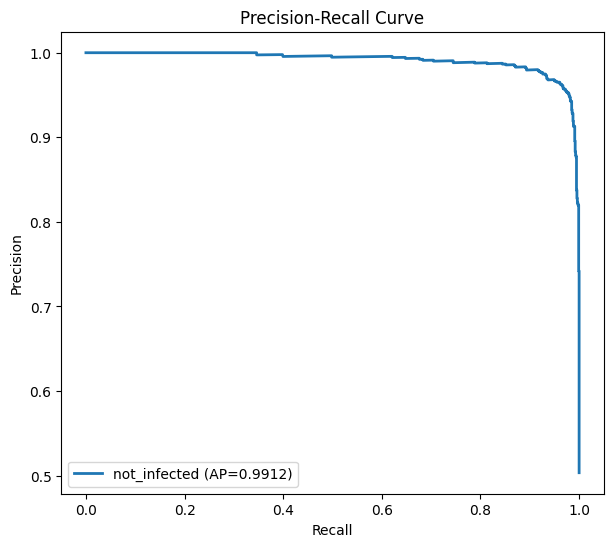

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

precision_curve, recall_curve, _ = precision_recall_curve(
    y_true,
    y_pred_prob[:, 1]
)

ap = average_precision_score(
    y_true,
    y_pred_prob[:, 1]
)

plt.plot(
    recall_curve,
    precision_curve,
    lw=2,
    label=f'{class_names[1]} (AP={ap:.4f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()